# CRISP-DM: Donor Amount Uplift (180 days)

**Analytics goal:** Identify donors **likely to increase gift size** within a 180-day horizon so major-gift and stewardship teams can prioritize asks and cultivation.

| CRISP-DM phase | Where it appears |
|----------------|------------------|
| **1. Business understanding** | Next section + Business KPI mapping |
| **2. Data understanding** | Donor snapshot, audits |
| **3. Data preparation** | `src.features` |
| **4. Modeling** | Predictive + explanatory uplift models |
| **5. Evaluation** | Metrics and business readout |
| **6. Deployment** | Prioritization for fundraising outreach |

### 1) Business understanding (donation uplift)

**Organizational context:** Growing **average gift** and **donor lifetime value** sustains programs without always acquiring new donors—especially important when acquisition costs are high. The organization needs to know **whom to cultivate** for deeper engagement without alienating the base.

**Business objectives**
- Prioritize donors for **higher-touch asks**, personalized stewardship, or upgrade campaigns where incremental **revenue lift** justifies outreach cost.
- Protect **donor trust**: avoid aggressive solicitation of donors unlikely to uplift or sensitive to frequency.

**Stakeholders and decisions**
| Stakeholder | Decision enabled |
|-------------|------------------|
| **Fundraising Director / major gifts** | Portfolio ranking, ask timing, tiered strategies |
| **Donor services** | Segmentation for campaigns and events |
| **Finance / leadership** | Forecasting and ROI of cultivation spend |

**Measurable success criteria (examples)**
- **+10% incremental donated amount** (or agreed metric) among targeted donors with **≤12%** (or agreed) increase in outreach cost; monitor **opt-out** and complaint rates as guardrails.

**Constraints**
- **Proxy label:** “Uplift” in history is **not** a randomized experiment—associations reflect past asks and macro trends; avoid causal overclaim.
- **Equity:** Capacity to give varies; models should be reviewed for **fairness** across segments where business ethics require it.
- **Privacy:** Use minimum necessary data; align with CRM policies.

**Costs of errors**
- **False positive:** Expensive stewardship on donors who will not increase—opportunity cost and possible fatigue.
- **False negative:** Missed revenue from donors who would have responded to a well-timed ask.

**Use of outputs:** **Ranked lists** for campaigns—not automatic ask amounts without human judgment.

In [1]:
import os, sys
from pathlib import Path


def _find_ml_pipelines_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        mp = base / "ml-pipelines"
        if mp.is_dir() and (mp / "requirements.txt").is_file():
            return mp
        if base.name == "ml-pipelines" and (base / "requirements.txt").is_file():
            return base
    raise RuntimeError(
        "Could not find ml-pipelines/requirements.txt. Open the Lighthouse-Sanctuary repo "
        "or the ml-pipelines folder, then use Run All."
    )


_boot_path = _find_ml_pipelines_root() / "pipeline_common" / "notebook_bootstrap.py"
_ns = globals()
_ns["__file__"] = str(_boot_path)
exec(compile(_boot_path.read_text(encoding="utf-8"), str(_boot_path), "exec"), _ns)

import numpy as np
import pandas as pd

from src.db import load_env, build_engine
from src.features import build_frame, split_xy
from src.modeling import train_predictive_and_explanatory


## Business KPI mapping (operational measures)

These bullets make the **business objectives** in Business understanding measurable for programs and leadership.

- Stakeholder owner: Fundraising Director
- Decision enabled: prioritize donors for higher-touch ask strategy
- Primary KPI: uplift in donated amount among targeted donors
- Guardrail KPIs: donor fatigue/opt-out rate, outreach cost per additional peso raised
- Minimum success criteria: +10% incremental donation amount at <=12% increase in outreach cost

## Problem Framing
- Predictive: classify donors likely to increase donation amount within 180 days.
- Explanatory: identify donor characteristics associated with amount uplift.
- Caveat: this is a proxy for "would give more if asked"; no direct intervention flag exists.

In [2]:
load_env('.env')
engine = build_engine(os.getenv('DB_PROFILE', 'local'))
df = build_frame(engine)
X, y = split_xy(df)
print(df.shape, 'uplift rate=', round(y.mean(),4))
df.head()

(347, 13) uplift rate= 0.4726


,supporter_id,snapshot_date,donation_value,amount_to_date,avg_amount_to_date,donation_count_to_date,supporter_type,relationship_type,region,acquisition_channel,amount_next_180d,max_date,uplift_180d
0,1,2023-03-25,774.61,774.61,774.610,1,SocialMediaAdvocate,Local,Luzon,SocialMedia,1590.05,2026-03-01,1
1,1,2023-06-24,606.91,1381.52,690.760,2,SocialMediaAdvocate,Local,Luzon,SocialMedia,3611.28,2026-03-01,1
2,1,2023-07-01,663.94,2045.46,681.820,3,SocialMediaAdvocate,Local,Luzon,SocialMedia,2947.34,2026-03-01,1
3,1,2023-07-02,300.00,2345.46,586.365,4,SocialMediaAdvocate,Local,Luzon,SocialMedia,2647.34,2026-03-01,1
4,1,2023-07-23,19.20,2364.66,472.932,5,SocialMediaAdvocate,Local,Luzon,SocialMedia,4020.24,2026-03-01,1


In [3]:
# Data Understanding Audit: missingness + anomaly checks
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(10).to_frame('missing_pct'))

audit = {
    'rows': len(df),
    'uplift_positive_rate': float(y.mean()),
    'negative_donation_rows': int((df['donation_value'] < 0).sum()),
    'amount_to_date_lt_snapshot_rows': int((df['amount_to_date'] < df['donation_value']).sum()),
}
print('Audit summary:', audit)

print('Feature rationale: donor history + profile features tie directly to expected capacity/propensity to increase giving.')

,missing_pct
supporter_id,0.0
snapshot_date,0.0
donation_value,0.0
amount_to_date,0.0
avg_amount_to_date,0.0
donation_count_to_date,0.0
supporter_type,0.0
relationship_type,0.0
region,0.0
acquisition_channel,0.0


Audit summary: {'rows': 347, 'uplift_positive_rate': 0.47262247838616717, 'negative_donation_rows': 0, 'amount_to_date_lt_snapshot_rows': 0}
Feature rationale: donor history + profile features tie directly to expected capacity/propensity to increase giving.


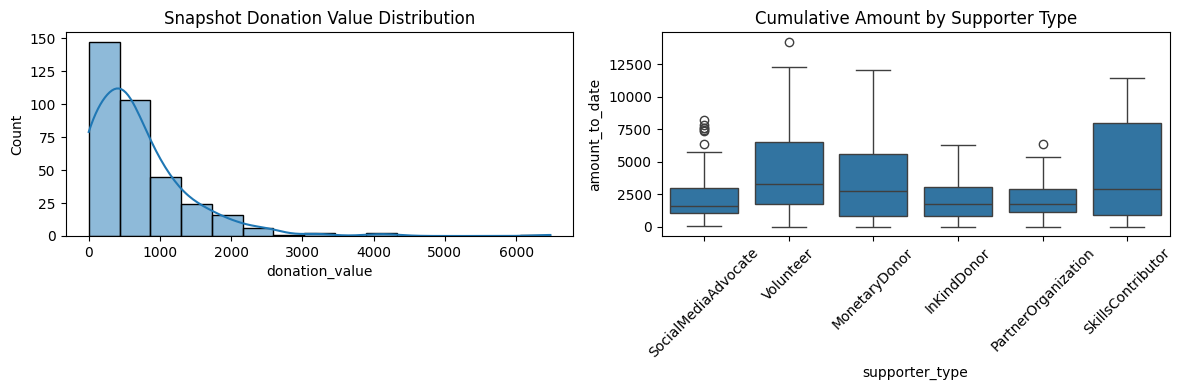

In [4]:
import numpy as np
import subprocess
import sys

try:
    import seaborn as sns
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'matplotlib'])
    import seaborn as sns
    import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['donation_value'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Snapshot Donation Value Distribution')

sns.boxplot(data=df, x='supporter_type', y='amount_to_date', ax=axes[1])
axes[1].set_title('Cumulative Amount by Supporter Type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [5]:
rf, rf_metrics, logit, logit_metrics, coef_df = train_predictive_and_explanatory(X, y)
print('Predictive RF metrics:', {k: round(v,4) for k,v in rf_metrics.items()})
print('Explanatory logistic metrics:', {k: round(v,4) for k,v in logit_metrics.items()})
display(coef_df.head(12))
display(coef_df.tail(12).sort_values('coefficient'))

Predictive RF metrics: {'roc_auc': 0.7131, 'pr_auc': 0.7039}
Explanatory logistic metrics: {'roc_auc': 0.7439, 'pr_auc': 0.7705}


,feature,coefficient,odds_ratio
6,cat__supporter_type_MonetaryDonor,0.520858,1.683472
19,cat__acquisition_channel_PartnerReferral,0.336126,1.399515
8,cat__supporter_type_SkillsContributor,0.320319,1.377567
4,num__donation_count_to_date,0.314647,1.369775
20,cat__acquisition_channel_SocialMedia,0.253209,1.288152
11,cat__relationship_type_International,0.250032,1.284066
17,cat__acquisition_channel_Church,0.245117,1.277771
16,cat__region_Visayas,0.227798,1.255831
15,cat__region_Mindanao,0.081657,1.085083
7,cat__supporter_type_PartnerOrganization,0.019262,1.019449


,feature,coefficient,odds_ratio
1,num__donation_value,-0.867891,0.419836
9,cat__supporter_type_SocialMediaAdvocate,-0.530707,0.588189
21,cat__acquisition_channel_Website,-0.375650,0.686843
14,cat__region_Luzon,-0.363258,0.695407
22,cat__acquisition_channel_WordOfMouth,-0.319118,0.726789
3,num__avg_amount_to_date,-0.246664,0.781403
5,cat__supporter_type_InKindDonor,-0.208280,0.811980
18,cat__acquisition_channel_Event,-0.193487,0.824080
13,cat__relationship_type_PartnerOrganization,-0.187332,0.829168
10,cat__supporter_type_Volunteer,-0.175257,0.839241


In [6]:
# Threshold tuning + FP/FN cost table for donor uplift targeting
uplift_proba_full = logit.predict_proba(X)[:, 1]
thresholds = np.arange(0.1, 0.95, 0.05)
fp_cost = 1.0
fn_cost = 2.5
rows = []
for t in thresholds:
    pred = (uplift_proba_full >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    total_cost = fp_cost * fp + fn_cost * fn
    rows.append({'threshold': round(float(t), 2), 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn), 'total_cost': float(total_cost)})

cost_df = pd.DataFrame(rows).sort_values('total_cost').reset_index(drop=True)
display(cost_df.head(10))
best_t = float(cost_df.loc[0, 'threshold'])
print(f'Selected threshold by cost minimization: {best_t:.2f}')

,threshold,tp,fp,fn,tn,total_cost
0,0.30,151,113,13,70,145.5
1,0.35,141,96,23,87,153.5
2,0.25,155,133,9,50,155.5
3,0.40,132,78,32,105,158.0
4,0.20,159,149,5,34,161.5
5,0.15,162,157,2,26,162.0
6,0.45,125,69,39,114,166.5
7,0.10,162,171,2,12,176.0
8,0.50,111,55,53,128,187.5
9,0.55,96,43,68,140,213.0


Selected threshold by cost minimization: 0.30


## Evaluation In Business Terms
- False positives: outreach to donors unlikely to increase giving.
- False negatives: missed opportunities for tailored asks.
Use uplift scores to prioritize who receives premium ask strategies.

## Operationalization Policy + Monitoring

- Threshold policy: choose minimum-cost threshold from FP/FN table; default fallback 0.50.
- Action bands: high uplift probability -> premium ask, medium -> standard ask, low -> nurture-only touchpoints.
- Retraining cadence: monthly retrain, with early retrain when PR-AUC degrades >15% or feature drift alerts fire.
- Monitoring references:
  - `ml-pipelines/integration/pipeline_registry.yaml`
  - `ml-pipelines/integration/monitoring_spec.md`
  - `ml-pipelines/integration/README.md`

## Causal Caveat
Associations do not prove asking caused uplift; validate with controlled campaigns.

## Deployment Notes
Serve donor uplift probability in a fundraiser dashboard and rank donor segments for outreach planning.